### Overview

1) Understand the shape of the data (Histograms, box plots, etc.)
2) Data Cleaning
3) Data Exploration
4) Feature Engineering
5) Data Preprocessing for Model
6) Basic Model Building
7) Model Tuning
8) Ensemble Modle Building
9) Results

In [1]:
# Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
# print all files in the titanic directory
for dirname, _, filenames in os.walk("../data"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/test.csv
../data/train.csv
../data/gender_submission.csv


In [2]:
training = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(training.head())
print(test.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [3]:
training['train_test'] = 1
test['train_test'] = 0
test['Survived'] = np.nan
all_data = pd.concat([training,test])

%matplotlib inline
all_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_test'],
      dtype='str')

--- DATA INFO ---
<class 'pandas.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   str    
 4   Sex          1309 non-null   str    
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   str    
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    str    
 11  Embarked     1307 non-null   str    
 12  train_test   1309 non-null   int64  
dtypes: float64(3), int64(5), str(5)
memory usage: 143.2 KB


--- NUMERICAL SUMMARY ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,1309.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479,0.680672
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668,0.466394
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000,1.000000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200,1.000000


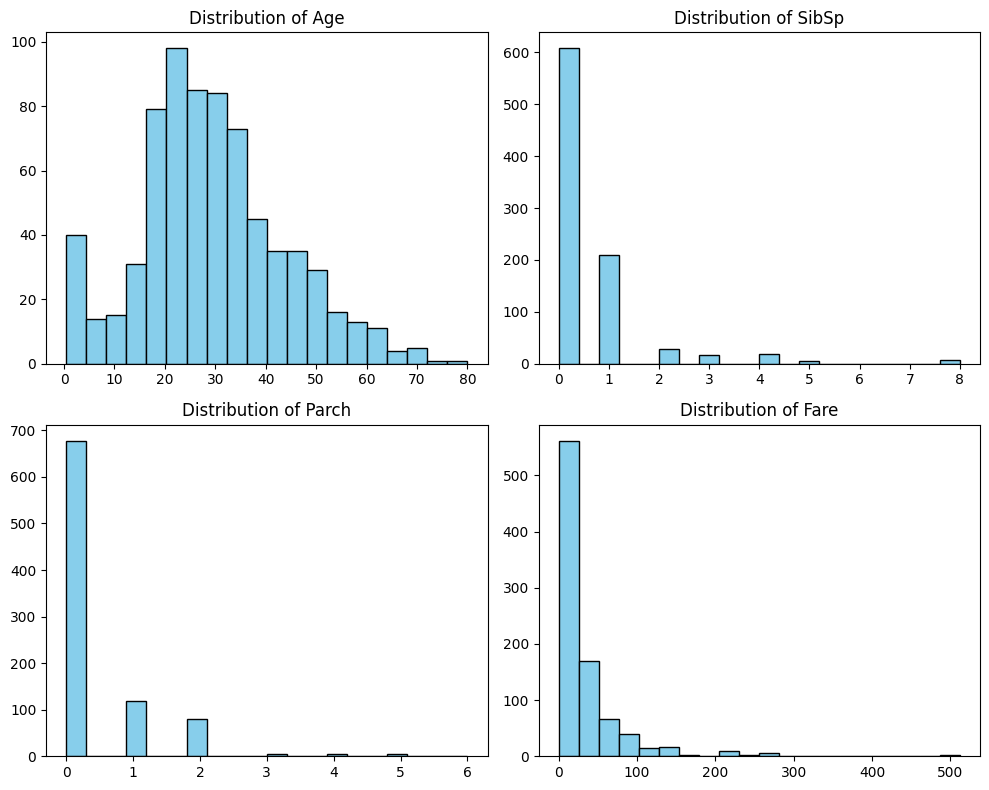

In [4]:
# 1. Check the data types and see where we have missing values (nulls)
print("--- DATA INFO ---")
all_data.info()
print("\n" + "="*50 + "\n")

# 2. Get basic statistics for our numerical columns (mean, min, max, etc.)
print("--- NUMERICAL SUMMARY ---")
display(all_data.describe())
print("\n" + "="*50 + "\n")

# 3. Separate numerical and categorical columns for easier analysis later
df_num = training[['Age','SibSp','Parch','Fare']]
df_cat = training[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

# 4. Plot histograms for all the numerical variables to understand their distributions
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for i, col in enumerate(df_num.columns):
    plt.subplot(2, 2, i + 1)
    plt.hist(df_num[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


In [5]:
# 1. First, make a copy of the original combined dataset
df_clean = all_data.copy()

# 2. Fill missing 'Age' with the median age of everyone on board
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# 3. Fill missing 'Fare' with the median fare
df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

# 4. Fill missing 'Embarked' with the most common value ('S')
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# 5. Create our new 'has_cabin' feature (1 if not null, 0 if null)
df_clean['has_cabin'] = df_clean['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# Now we can safely drop the original 'Cabin' column from our clean dataset
df_clean.drop(['Cabin'], axis=1, inplace=True)

# Let's check our new clean dataframe for missing values!
print("--- MISSING VALUES IN df_clean ---")
print(df_clean.isnull().sum())


--- MISSING VALUES IN df_clean ---
PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
train_test       0
has_cabin        0
dtype: int64


========== DATA INSIGHTS ==========

Survival Rate by Sex:
Sex
female     74.2%
male      18.89%
Name: Survived, dtype: str


Survival Rate by Passenger Class:
Pclass
1    62.96%
2    47.28%
3    24.24%
Name: Survived, dtype: str


Survival Rate by Cabin Availability:
has_cabin
0    29.99%
1    66.67%
Name: Survived, dtype: str


Survival Rate by Embarkation Port:
Embarked
C    55.36%
Q    38.96%
S     33.9%
Name: Survived, dtype: str





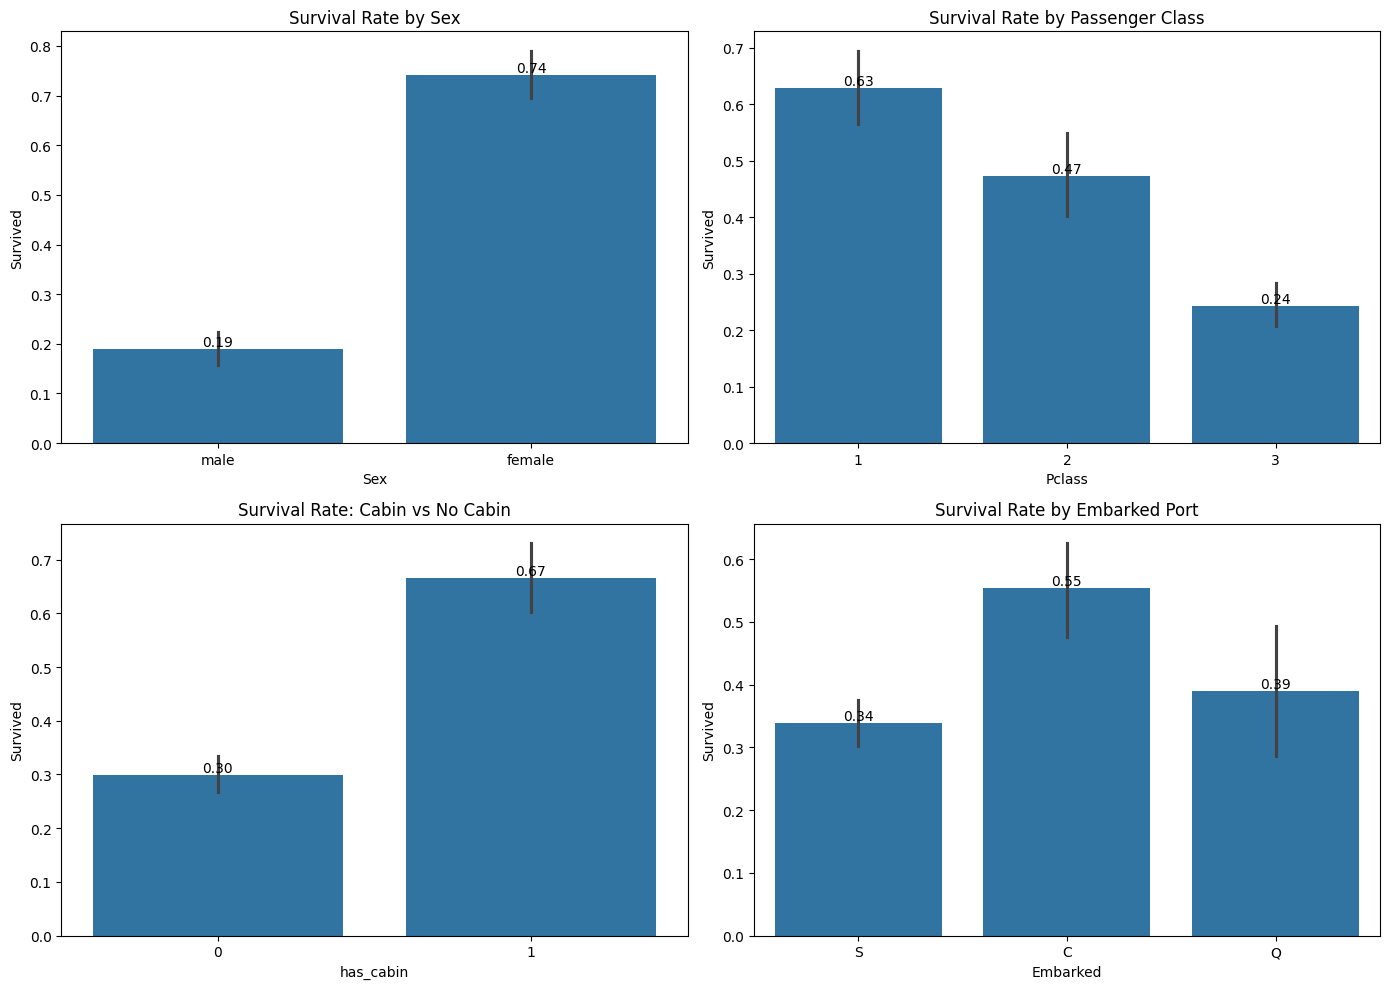

In [6]:
# Create a new cell and let's explore our cleaned training data
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# We only want to look at the training data where we actually have survival answers
df_train = df_clean[df_clean['train_test'] == 1].copy()

print("========== DATA INSIGHTS ==========\n")

# 1. Survival by Sex
sex_survival = df_train.groupby('Sex')['Survived'].mean()
print("Survival Rate by Sex:")
print((sex_survival * 100).round(2).astype(str) + "%")
print("\n")

# 2. Survival by Passenger Class
pclass_survival = df_train.groupby('Pclass')['Survived'].mean()
print("Survival Rate by Passenger Class:")
print((pclass_survival * 100).round(2).astype(str) + "%")
print("\n")

# 3. Survival by Cabin Feature
cabin_survival = df_train.groupby('has_cabin')['Survived'].mean()
print("Survival Rate by Cabin Availability:")
print((cabin_survival * 100).round(2).astype(str) + "%")
print("\n")

# 4. Survival by Embarked Port
embarked_survival = df_train.groupby('Embarked')['Survived'].mean()
print("Survival Rate by Embarkation Port:")
print((embarked_survival * 100).round(2).astype(str) + "%")
print("\n")

print("====================================\n")

# ---- PLOTS ----

# Set up our grid for plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival by Sex
sns.barplot(x='Sex', y='Survived', data=df_train, ax=axes[0, 0])
axes[0, 0].set_title('Survival Rate by Sex')
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='%.2f')

# 2. Survival by Passenger Class
sns.barplot(x='Pclass', y='Survived', data=df_train, ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Passenger Class')
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container, fmt='%.2f')

# 3. Survival by has_cabin
sns.barplot(x='has_cabin', y='Survived', data=df_train, ax=axes[1, 0])
axes[1, 0].set_title('Survival Rate: Cabin vs No Cabin')
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%.2f')

# 4. Survival by Embarked
sns.barplot(x='Embarked', y='Survived', data=df_train, ax=axes[1, 1])
axes[1, 1].set_title('Survival Rate by Embarked Port')
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

========== FEATURE ANALYSIS ==========

Survival by Family Size
            count  Survival %
FamilySize                   
1             537       30.35
2             161       55.28
3             102       57.84
4              29       72.41
5              15       20.00
6              22       13.64
7              12       33.33
8               6        0.00
11              7        0.00


Survival by Being Alone
         count  Survival %
IsAlone                   
0          354       50.56
1          537       30.35


Survival by Passenger Title
        count  Survival %
Title                    
Master     40       57.50
Miss      185       70.27
Mr        517       15.67
Mrs       126       79.37
Rare       23       34.78





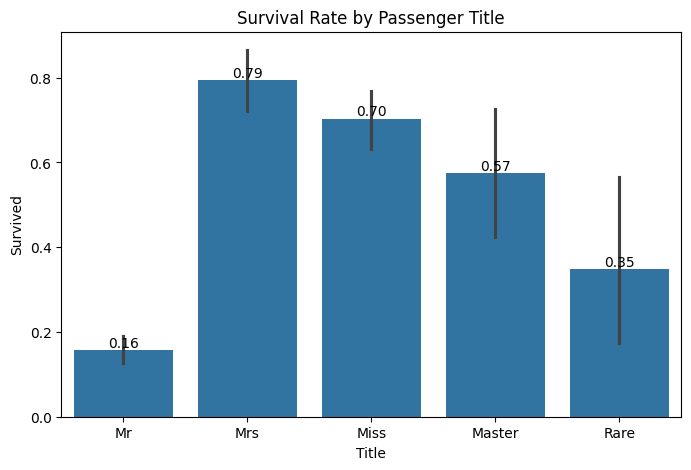

In [7]:
# 1. Create 'FamilySize'
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# 2. Create 'IsAlone'
df_clean['IsAlone'] = df_clean['FamilySize'].apply(lambda x: 1 if x == 1 else 0)

# 3. Extract 'Title' from the Name column
df_clean['Title'] = df_clean['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]

# Clean rare titles
title_replacements = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Capt': 'Rare', 'Sir': 'Rare', 'Don': 'Rare', 'Lady': 'Rare',
    'the Countess': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
df_clean['Title'] = df_clean['Title'].replace(title_replacements)

# Work only with training data
df_train = df_clean[df_clean['train_test'] == 1].copy()

print("========== FEATURE ANALYSIS ==========\n")

# --- Family Size ---
family_stats = df_train.groupby('FamilySize')['Survived'].agg(['count','mean'])
family_stats['Survival %'] = (family_stats['mean']*100).round(2)

print("Survival by Family Size")
print(family_stats[['count','Survival %']])
print("\n")

# --- Alone vs Not Alone ---
alone_stats = df_train.groupby('IsAlone')['Survived'].agg(['count','mean'])
alone_stats['Survival %'] = (alone_stats['mean']*100).round(2)

print("Survival by Being Alone")
print(alone_stats[['count','Survival %']])
print("\n")

# --- Title ---
title_stats = df_train.groupby('Title')['Survived'].agg(['count','mean'])
title_stats['Survival %'] = (title_stats['mean']*100).round(2)

print("Survival by Passenger Title")
print(title_stats[['count','Survival %']])
print("\n")

print("======================================\n")

# -------- PLOT --------

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='Title', y='Survived', data=df_train)

plt.title('Survival Rate by Passenger Title')

# Add exact percentages on bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f')

plt.show()

# Drop columns we don't need anymore
df_clean.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [8]:
# 1. Select the columns that are categorical text and need to be converted to numbers
categorical_cols = ['Pclass', 'Sex', 'Embarked', 'Title']

# 2. Convert these categorical columns to dummy variables (One-Hot Encoding)
# We convert Pclass to a string first so pandas knows it's a category, not a continuous number
df_clean['Pclass'] = df_clean['Pclass'].astype(str)
df_dummies = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 3. Split the data back into the original Train and Test sets
# Remember earlier we set 'train_test' = 1 for train data and 0 for test data
X_train_full = df_dummies[df_dummies['train_test'] == 1].drop(['train_test'], axis=1)
X_test = df_dummies[df_dummies['train_test'] == 0].drop(['train_test', 'Survived'], axis=1)

# 4. Separate the 'Survived' column (our target variable 'Y') from our training features ('X')
y_train = X_train_full['Survived']
X_train = X_train_full.drop(['Survived'], axis=1)

# Let's peek at what our final, machine-ready training data looks like
print("--- FINAL TRAINING DATA SHAPE ---")
print(X_train.shape)
print("\n--- FIRST 3 ROWS OVERVIEW ---")
display(X_train.head(3))


--- FINAL TRAINING DATA SHAPE ---
(891, 16)

--- FIRST 3 ROWS OVERVIEW ---


,Age,SibSp,Parch,Fare,has_cabin,FamilySize,IsAlone,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,22.0,1,0,7.2500,0,2,0,False,True,True,False,True,False,True,False,False
1,38.0,1,0,71.2833,1,2,0,False,False,False,False,False,False,False,True,False
2,26.0,0,0,7.9250,0,1,1,False,True,False,False,True,True,False,False,False


In [9]:
# Import the machine learning tools from the standard 'scikit-learn' library
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 1. Initialize the Random Forest Model
# random_state=1 just ensures that we get the same 'random' results every time we run this block
rf_model = RandomForestClassifier(random_state=1)

# 2. Evaluate the model using "Cross-Validation"
# Cross-validation splits our training data into 5 chunks. It trains on 4 chunks and tests on the 1 chunk,
# repeating this 5 times so every chunk gets to be the test set once.
# This gives us a much more honest assessment of how accurate our model is.
scores = cross_val_score(rf_model, X_train, y_train, cv=5)

print("--- BASIC RANDOM FOREST SCORES ---")
print(f"Accuracy across 5 folds: {scores}")
print(f"Average Accuracy: {scores.mean() * 100:.2f}%")

# 3. Finally, let's train (fit) the model on the full training dataset
rf_model.fit(X_train, y_train)

# 4. Let's look at which features the model thought were most important!
import pandas as pd
rf_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})
rf_importance = rf_importance.sort_values('Importance', ascending=False)
display(rf_importance.head(10))


--- BASIC RANDOM FOREST SCORES ---
Accuracy across 5 folds: [0.82681564 0.7752809  0.85955056 0.75842697 0.83707865]
Average Accuracy: 81.14%


,Feature,Importance
3,Fare,0.219210
0,Age,0.217338
13,Title_Mr,0.136757
9,Sex_male,0.115066
8,Pclass_3,0.046079
5,FamilySize,0.045412
4,has_cabin,0.040034
14,Title_Mrs,0.034423
1,SibSp,0.031766
12,Title_Miss,0.030387


In [10]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# 1. Define the "grid" of settings we want to test
param_grid = {
    'n_estimators': [50, 100, 200],      # Try making forests with 50, 100, and 200 trees
    'max_depth': [5, 10, None],          # Try limiting the depth of the trees
    'min_samples_split': [2, 5, 10]      # Don't split a leaf if it has fewer than this many passengers
}

# 2. Set up the Grid Search attached to our Random Forest
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=1), 
                           param_grid=param_grid, 
                           cv=5,            # Use 5-fold cross validation again
                           verbose=1,       # Print progress
                           n_jobs=-1)       # Use all CPU cores to calculate faster

# 3. FIT THE GRID SEARCH (This might take a few seconds as it tries 27 different combinations!)
print("--- STARTING GRID SEARCH ---")
grid_search.fit(X_train, y_train)

# 4. Print the best results
print("\n--- BEST MODEL FOUND ---")
print(f"Best Score: {grid_search.best_score_ * 100:.2f}%")
print(f"Best Settings: {grid_search.best_params_}")

# 5. Save the best model for later
best_rf_model = grid_search.best_estimator_


--- STARTING GRID SEARCH ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits



--- BEST MODEL FOUND ---
Best Score: 83.28%
Best Settings: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
